In [1]:
from functools import reduce
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def count_elements(t):
    """
    input shoule be like tensor<.*xf32>
    """
    return reduce(lambda acc, x: acc * x, map(int, t[7:-5 if "f32" in t else -4].split("x")))

def get_tensors(line):
    tensors = []
    while "tensor<" in line:
        begin = line.index("tensor<")
        end = line.index(">") + 1
        tensor, line = line[begin:end], line[end:]
        if tensor:
            tensors.append(tensor)
    return tensors

def get_rw(line):    
    def get_count(subline):
        tensors = get_tensors(subline)
        return reduce(lambda acc, x: acc + count_elements(x), tensors, 0)
    
    def get_r():
        if "ins" in line:
            ins_index = line.index("ins")
            outs_index = line.index("outs")
            return get_count(line[ins_index:outs_index])
        return 0
    
    def get_w():
        outs_index = line.index("outs")
        return get_count(line[outs_index:])
    
    return get_r(), get_w()

def get_dataframe(depth, ur, uw, fr, fw):
    df = pd.DataFrame()
    count = [ur, uw, ur + uw, fr, fw, fr + fw]
    label = ["Read", "Write", "Read and Write", "Read (Fused)", "Write (Fused)", "Read and Write (Fused)"]
    
    for c, l in zip(count, label):
        df = pd.concat([
            df, 
            pd.DataFrame({
                "depth": depth,
                "label": l,
                "count": c
            }, index=[0])
        ])
        
    return df

## ResNet

Text(0.5, 1.0, 'I/O Estimation in backward CG of ResNet')

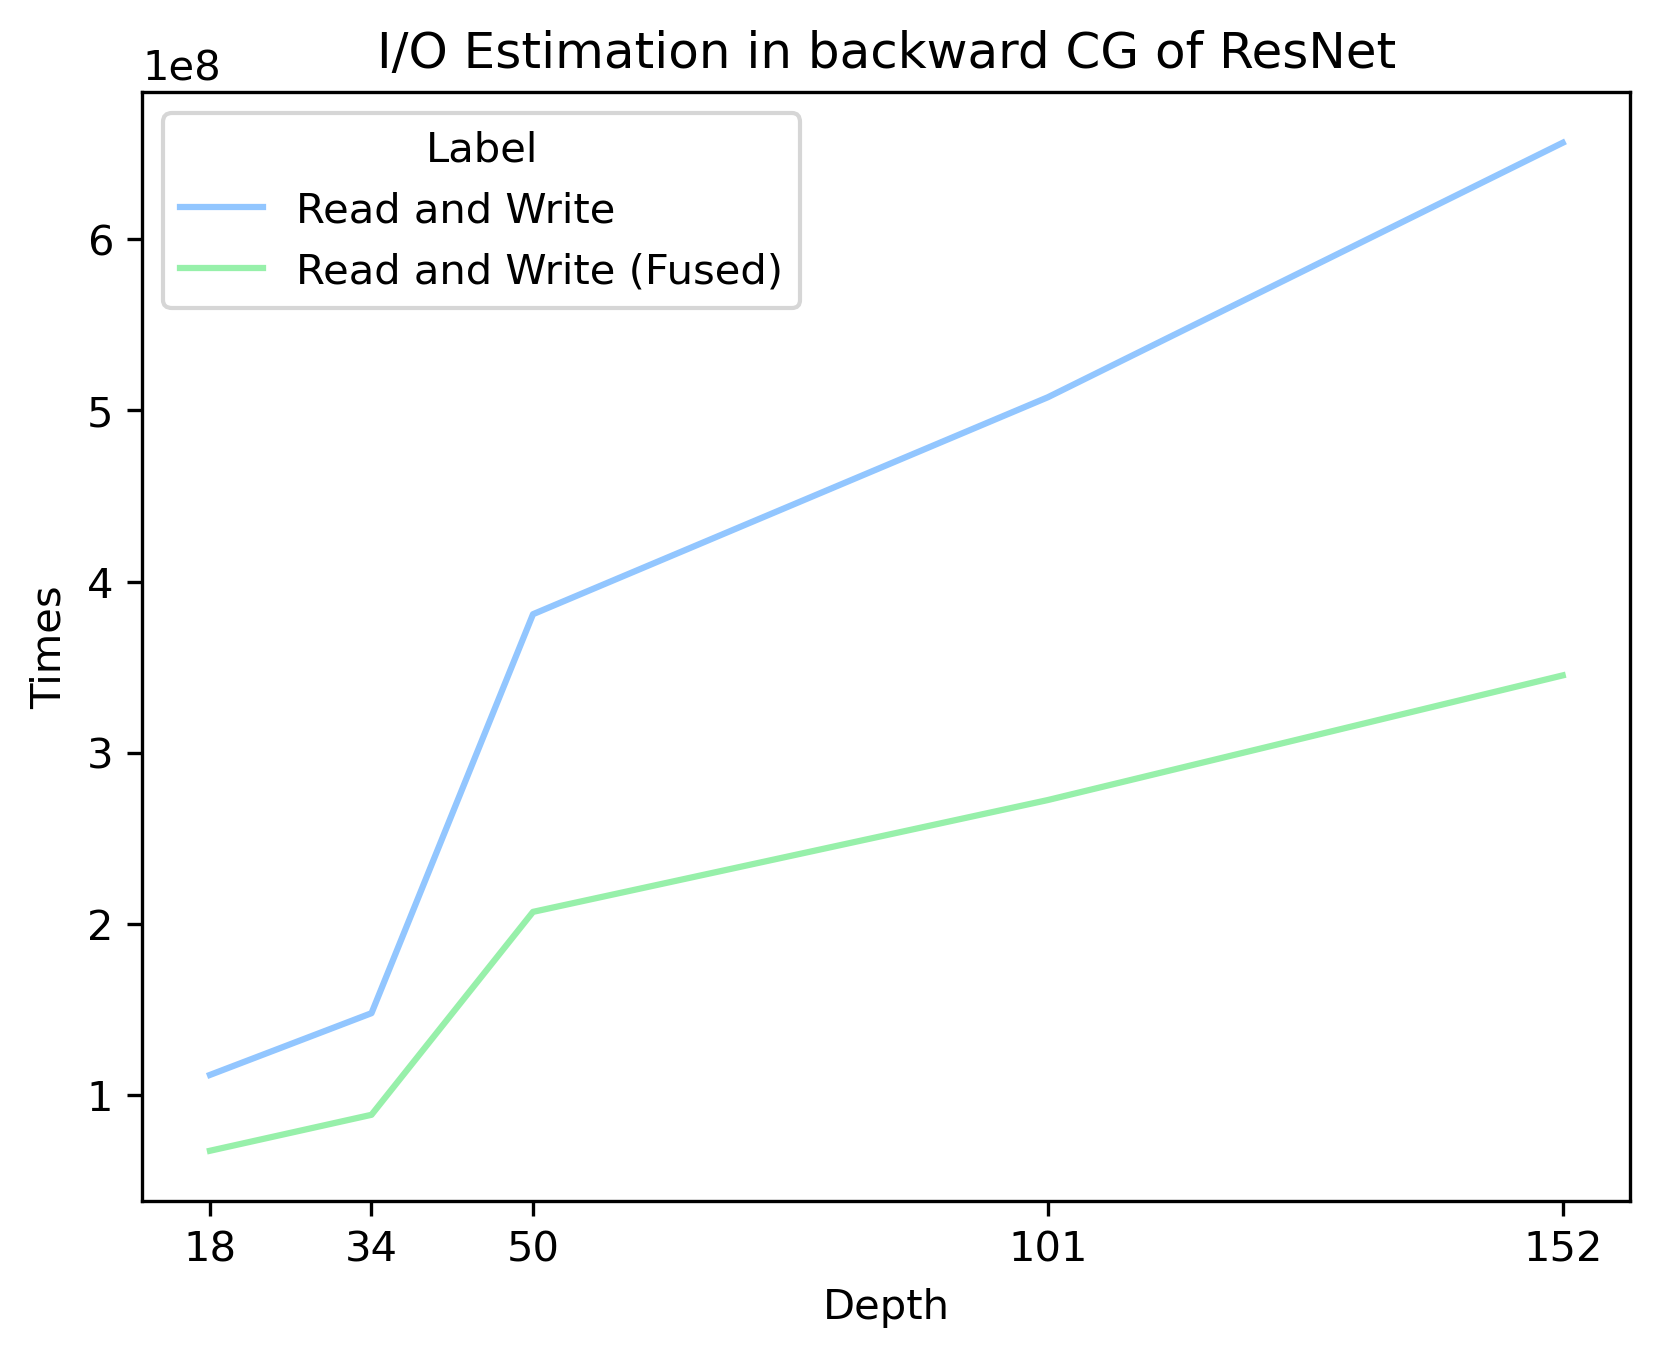

In [2]:
resnet_df = pd.DataFrame()
depths = [18, 34, 50, 101, 152]

for depth in depths:
    unfused_read = unfused_write = 0
    with open(f"ResNet/resnet{depth}-unfused.mlir") as f:
        mlir = f.read()
    for line in filter(lambda x: "ins" in x or "outs" in x, mlir[mlir.index("dforward"):].splitlines()):
        r, w = get_rw(line)
        unfused_read += r
        unfused_write += w
    
    fused_read = fused_write = 0
    with open(f"ResNet/resnet{depth}-fused.mlir") as f:
        mlir = f.read()
    for line in filter(lambda x: "ins" in x or "outs" in x, mlir[mlir.index("dforward"):].splitlines()):
        r, w = get_rw(line)
        fused_read += r
        fused_write += w
        
    resnet_df = pd.concat([resnet_df, get_dataframe(depth, unfused_read, unfused_write, fused_read, fused_write)])
    
plt.rcParams["figure.dpi"] = 300
plt.style.use("seaborn-v0_8-pastel")

sns.lineplot(resnet_df[(resnet_df.label == "Read and Write") | (resnet_df.label == "Read and Write (Fused)")], x="depth", y="count", hue="label")
plt.xlabel("Depth")
plt.ylabel("Times")
plt.xticks(depths)

plt.legend().set_title("Label")
plt.title("I/O Estimation in backward CG of ResNet")

## VGG

Text(0.5, 1.0, 'I/O Estimation in backward CG of VGG')

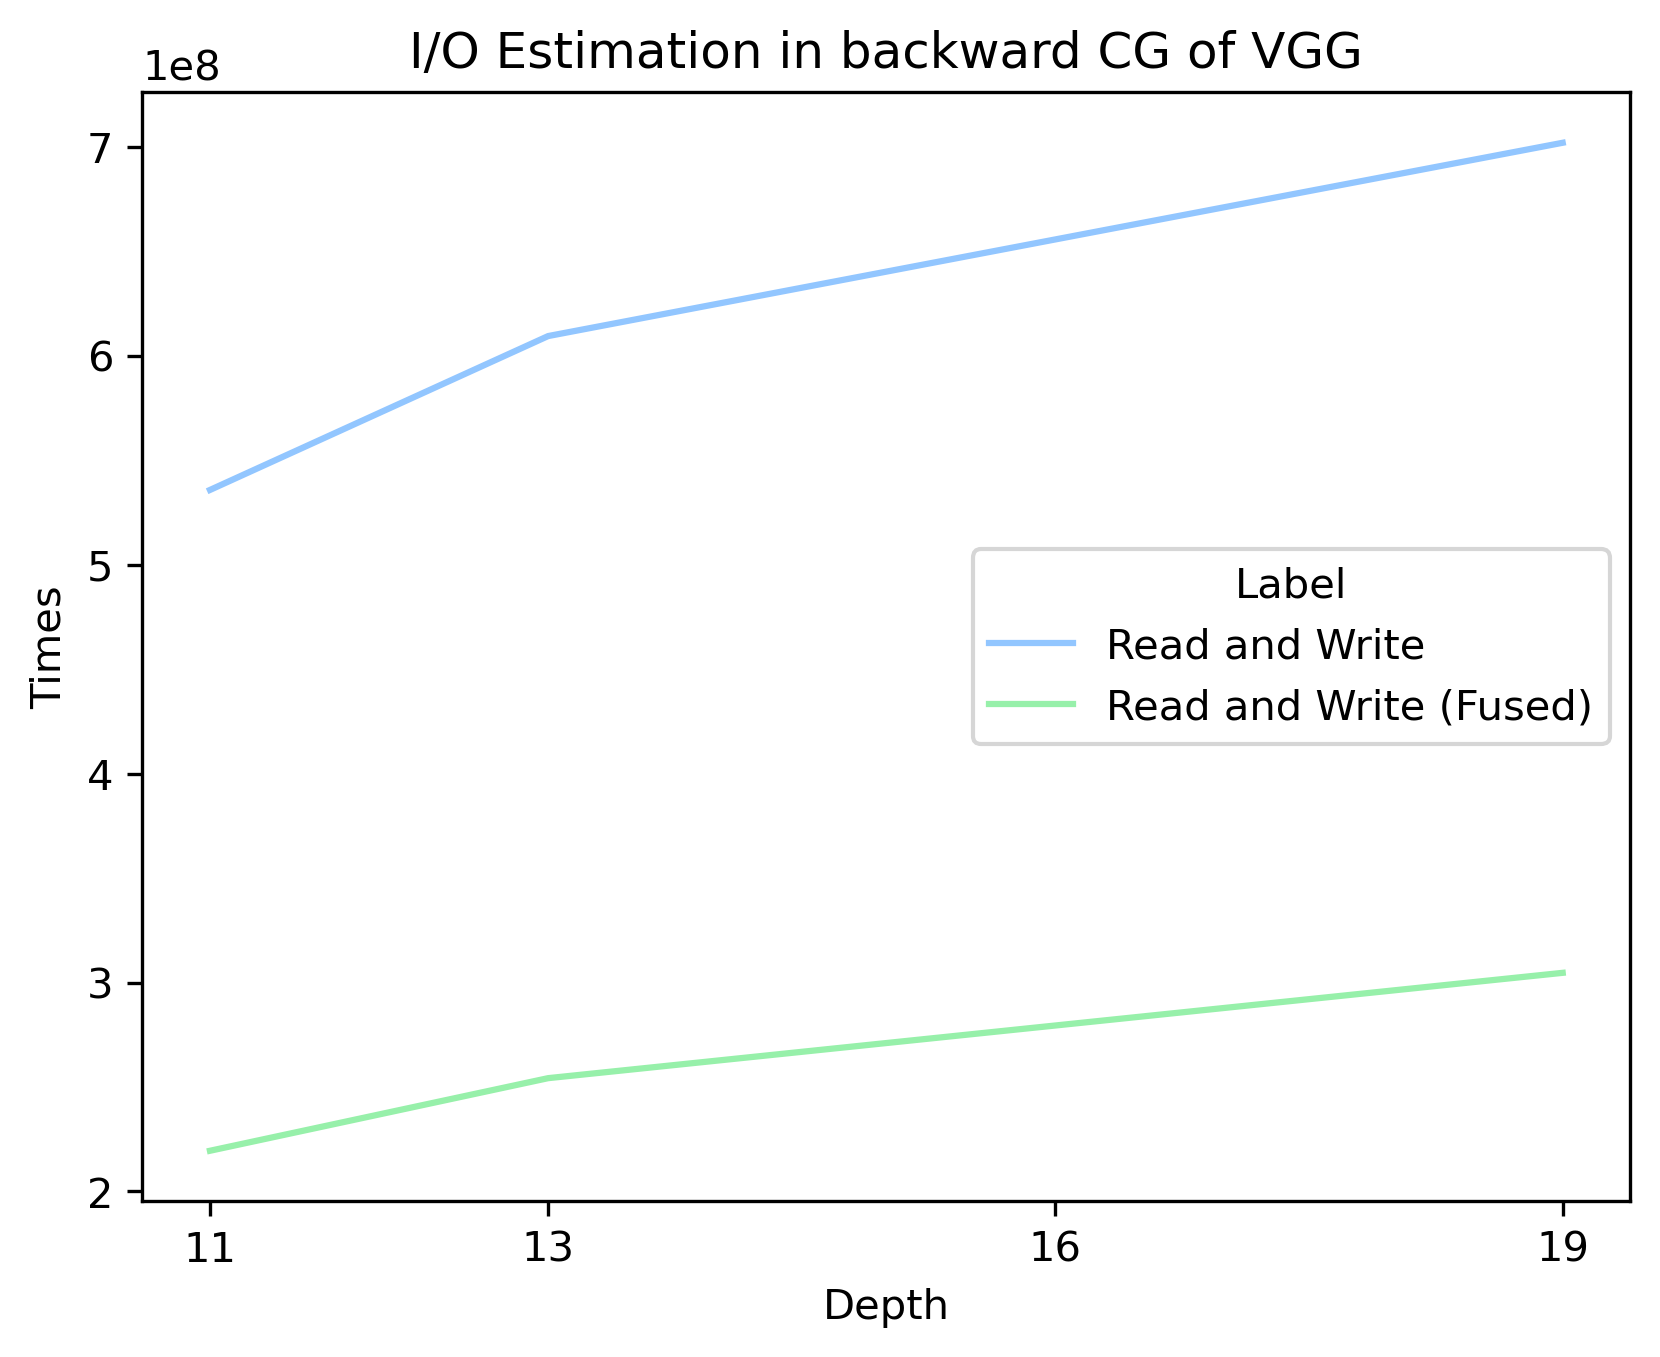

In [3]:
vgg_df = pd.DataFrame()
depths = [11, 13, 16, 19]

for depth in depths:
    unfused_read = unfused_write = 0
    with open(f"VGG/vgg{depth}-unfused.mlir") as f:
        mlir = f.read()
    for line in filter(lambda x: "ins" in x or "outs" in x, mlir[mlir.index("dforward"):].splitlines()):
        r, w = get_rw(line)
        unfused_read += r
        unfused_write += w
    
    fused_read = fused_write = 0
    with open(f"VGG/vgg{depth}-fused.mlir") as f:
        mlir = f.read()
    for line in filter(lambda x: "ins" in x or "outs" in x, mlir[mlir.index("dforward"):].splitlines()):
        r, w = get_rw(line)
        fused_read += r
        fused_write += w
        
    vgg_df = pd.concat([vgg_df, get_dataframe(depth, unfused_read, unfused_write, fused_read, fused_write)])
    
plt.rcParams["figure.dpi"] = 300
plt.style.use("seaborn-v0_8-pastel")

sns.lineplot(vgg_df[(vgg_df.label == "Read and Write") | (vgg_df.label == "Read and Write (Fused)")], x="depth", y="count", hue="label")
plt.xlabel("Depth")
plt.ylabel("Times")
plt.xticks(depths)

plt.legend().set_title("Label")
plt.title("I/O Estimation in backward CG of VGG")

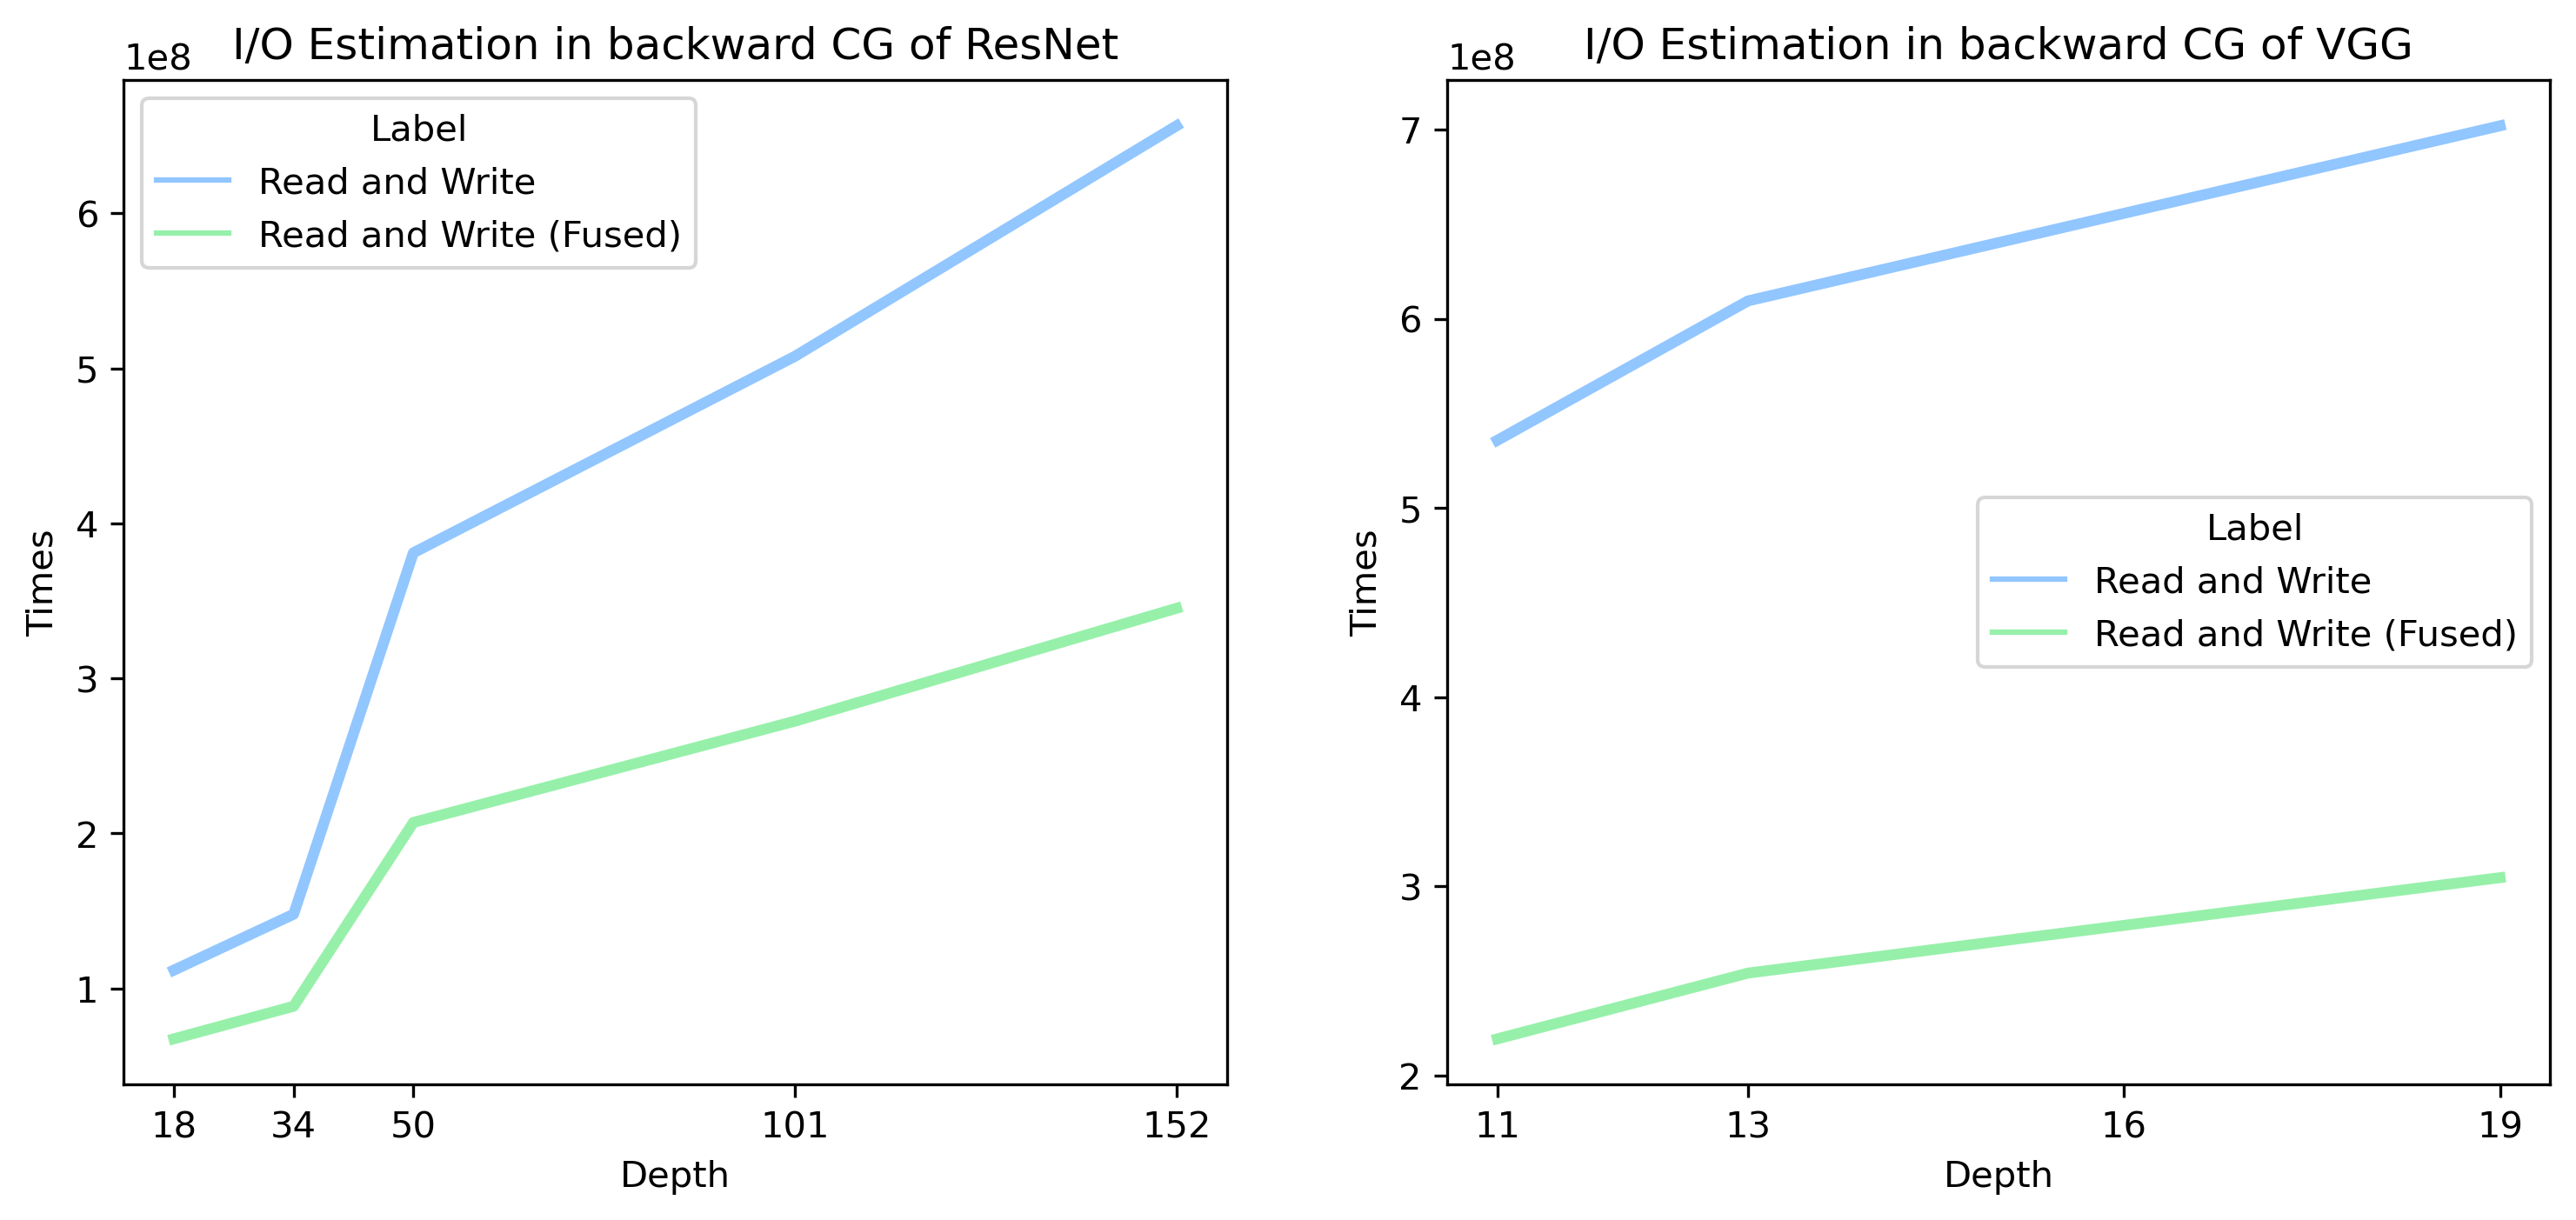

In [7]:
plt.rcParams["figure.figsize"] = (12, 5)
fig, (left, right) = plt.subplots(1, 2)
sns.lineplot(resnet_df[(resnet_df.label == "Read and Write") | (resnet_df.label == "Read and Write (Fused)")], x="depth", y="count", hue="label", linewidth=3, ax=left)
sns.lineplot(vgg_df[(vgg_df.label == "Read and Write") | (vgg_df.label == "Read and Write (Fused)")], x="depth", y="count", hue="label", linewidth=3, ax=right)

left.set_title("I/O Estimation in backward CG of ResNet")
left.set_xticks(list(set(resnet_df.depth)))
right.set_title("I/O Estimation in backward CG of VGG")
right.set_xticks(list(set(vgg_df.depth)))

for f in [left, right]:
    f.set_xlabel("Depth")
    f.set_ylabel("Times")
    f.legend().set_title("Label")
    
# plt.savefig("fusion.png", bbox_inches="tight", dpi=300, pad_inches=0.1)